In [2]:
import librosa
import numpy as np
import os

# [전처리 함수] 모든 음성 파일을 16000Hz, 5초 길이의 Mel-Spectrogram으로 변환
def preprocess_for_accuracy(file_path, target_sec=5):
    try:
        # 1. 로드
        y, sr = librosa.load(file_path, sr=16000)
        
        # 2. 길이 통일
        target_samples = sr * target_sec
        if len(y) > target_samples:
            y = y[:target_samples]
        else:
            y = np.pad(y, (0, target_samples - len(y)), 'constant')
            
        # 3. Mel-Spectrogram 추출
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)
        
        return S_dB
    except Exception as e:
        print(f"파일 에러: {file_path} -> {e}")
        return None

print("✅ 전처리 함수 준비 완료!")

✅ 전처리 함수 준비 완료!


🎉 성공! 데이터 크기: (128, 157)


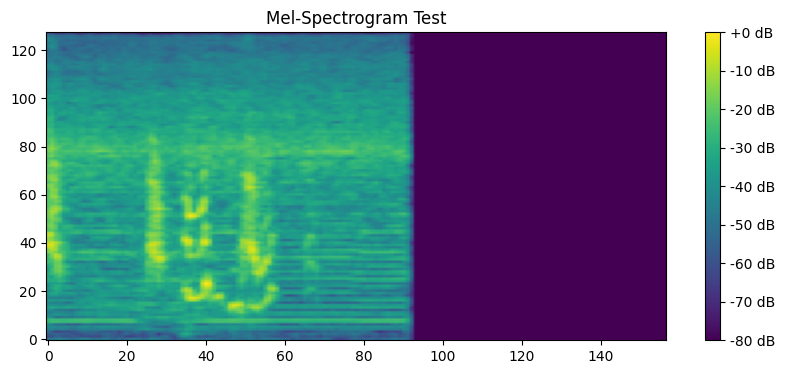

In [3]:
import matplotlib.pyplot as plt
import os

# 1. 테스트할 파일 경로 설정
# 왼쪽 탐색기에서 'Processed_Data_Full' 폴더 안의 .wav 파일을 찾아 우클릭 -> 'Copy Path' 하세요.
# 아래 경로가 맞는지 확인해 보세요!
test_path = "/home/ubuntu/raw_data/Processed_Data_Full/Scream/14.도움요청_31202_label_aug_710.wav"

if os.path.exists(test_path):
    # 2. 전처리 함수 실행
    feature = preprocess_for_accuracy(test_path)
    
    if feature is not None:
        print(f"🎉 성공! 데이터 크기: {feature.shape}")
        
        # 3. 시각화 (AI가 보는 소리의 모습입니다)
        plt.figure(figsize=(10, 4))
        plt.imshow(feature, aspect='auto', origin='lower')
        plt.colorbar(format='%+2.0f dB')
        plt.title('Mel-Spectrogram Test')
        plt.show()
else:
    print("❌ 파일을 찾을 수 없습니다. 경로를 다시 확인해 주세요.")

In [4]:
import os
import numpy as np
from tqdm import tqdm # 진행률 표시를 위한 도구

def batch_preprocess(root_path, save_path):
    # 저장할 폴더가 없으면 생성
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # 모든 .wav 파일 목록 가져오기
    audio_files = []
    for root, dirs, files in os.walk(root_path):
        for file in files:
            if file.endswith(".wav"):
                audio_files.append(os.path.join(root, file))
    
    print(f"총 {len(audio_files)}개의 파일을 찾았습니다.")

    # 자동 변환 루프
    for file_path in tqdm(audio_files, desc="전처리 중"):
        feature = preprocess_for_accuracy(file_path)
        if feature is not None:
            # 파일명을 기반으로 .npy 저장 (예: audio1.wav -> audio1.npy)
            file_name = os.path.basename(file_path).replace('.wav', '.npy')
            np.save(os.path.join(save_path, file_name), feature)

# 실행 (경로는 실제 구조에 맞춰 수정하세요)
# 원본 데이터 폴더: 'raw_data/Processed_Data_Full'
# 결과 저장 폴더: 'preprocessed_features'
batch_preprocess('raw_data/Processed_Data_Full', 'preprocessed_features')

총 57078개의 파일을 찾았습니다.


전처리 중: 100%|██████████| 57078/57078 [08:48<00:00, 107.96it/s]


In [9]:
import numpy as np
import os
from tqdm import tqdm

def augment_voice_from_folder(source_root, save_path, target_count=30000):
    # 저장 폴더 생성
    if not os.path.exists(save_path): os.makedirs(save_path)
    
    # 1. 원본 voice 폴더 경로 설정 (스크린샷 구조 기준)
    # 폴더 구조가 'Processed_Data_Full/voice'라면 아래와 같이 설정
    voice_dir = os.path.join(source_root, 'voice') 
    
    # 만약 폴더 이름이 다르면 여기서 수정하세요 (예: 'Scream', 'Speech' 등)
    if not os.path.exists(voice_dir):
        # 폴더명을 못 찾을 경우 현재 존재하는 폴더 목록 출력
        print(f"❌ '{voice_dir}' 폴더가 없습니다. 아래 목록 중 voice 폴더명을 확인하세요:")
        print(os.listdir(source_root))
        return

    voice_files = [f for f in os.listdir(voice_dir) if f.endswith('.wav')]
    print(f"찾은 원본 voice 파일: {len(voice_files)}개")

    # 2. 부족한 만큼 증강 (Mel-Spectrogram으로 변환하며 저장)
    needed_count = target_count - len(voice_files)
    
    for i in tqdm(range(needed_count), desc="Voice 데이터 뻥튀기 중"):
        random_file = np.random.choice(voice_files)
        file_path = os.path.join(voice_dir, random_file)
        
        # 우리가 만든 전처리 함수 사용
        feature = preprocess_for_accuracy(file_path)
        
        if feature is not None:
            # 랜덤 노이즈 살짝 추가
            noise = np.random.normal(0, 0.01, feature.shape)
            aug_feature = feature + noise
            
            # 저장
            np.save(os.path.join(save_path, f"aug_voice_{i}.npy"), aug_feature)

# 실행 (원본 폴더와 저장 폴더 지정)
augment_voice_from_folder('raw_data/Processed_Data_Full', 'preprocessed_features')

❌ 'raw_data/Processed_Data_Full/voice' 폴더가 없습니다. 아래 목록 중 voice 폴더명을 확인하세요:
['Scream', 'Notscream']


In [10]:
import numpy as np
import os
from tqdm import tqdm

def augment_scream_data(source_root, save_path, target_count=30000):
    # 저장 폴더 생성 (변환된 특징값이 모이는 곳)
    if not os.path.exists(save_path): os.makedirs(save_path)
    
    # 1. 원본 Scream 폴더 경로 설정
    scream_dir = os.path.join(source_root, 'Scream') 
    
    if not os.path.exists(scream_dir):
        print(f"❌ 폴더를 찾을 수 없습니다: {scream_dir}")
        return

    scream_files = [f for f in os.listdir(scream_dir) if f.endswith('.wav')]
    print(f"찾은 원본 Scream 파일: {len(scream_files)}개")

    # 2. 부족한 만큼 증강 시작
    current_count = len(scream_files)
    needed_count = target_count - current_count
    
    if needed_count <= 0:
        print("이미 목표 수량을 달성했습니다.")
        return

    for i in tqdm(range(needed_count), desc="Scream 데이터 증강 중"):
        random_file = np.random.choice(scream_files)
        file_path = os.path.join(scream_dir, random_file)
        
        # 아까 만든 전처리 함수로 Mel-Spectrogram 추출
        feature = preprocess_for_accuracy(file_path)
        
        if feature is not None:
            # 랜덤 화이트 노이즈 추가 (AI가 새로운 데이터로 인식하게 함)
            noise = np.random.normal(0, 0.005, feature.shape)
            aug_feature = feature + noise
            
            # 파일명 중복 안되게 저장
            np.save(os.path.join(save_path, f"aug_scream_{i}.npy"), aug_feature)

# 실행: raw_data 안의 Processed_Data_Full 폴더를 소스로 사용
augment_scream_data('raw_data/Processed_Data_Full', 'preprocessed_features')

찾은 원본 Scream 파일: 28539개


Scream 데이터 증강 중: 100%|██████████| 1461/1461 [00:13<00:00, 108.80it/s]


In [11]:
import os

def create_label_map(feature_path):
    all_files = os.listdir(feature_path)
    data_list = []
    labels = []

    for f in all_files:
        if f.endswith('.npy'):
            data_list.append(os.path.join(feature_path, f))
            # 파일명에 scream이 들어가면 1, 아니면 0 (Notscream)
            if 'scream' in f.lower():
                labels.append(1)
            else:
                labels.append(0)
                
    return data_list, labels

X_files, y_labels = create_label_map('preprocessed_features')
print(f"총 데이터 개수: {len(X_files)}")
print(f"Scream 데이터 개수: {sum(y_labels)}")

총 데이터 개수: 58539
Scream 데이터 개수: 1461


In [12]:
# target_count를 20,000으로 높여서 부족한 Scream을 더 채웁니다.
augment_scream_data('raw_data/Processed_Data_Full', 'preprocessed_features', target_count=20000)

# 다시 확인 (숫자가 올라갔는지 체크)
X_files, y_labels = create_label_map('preprocessed_features')
print(f"최종 총 데이터 개수: {len(X_files)}")
print(f"최종 Scream 데이터 개수: {sum(y_labels)}")

찾은 원본 Scream 파일: 28539개
이미 목표 수량을 달성했습니다.
최종 총 데이터 개수: 58539
최종 Scream 데이터 개수: 1461


In [14]:
import numpy as np
import tensorflow as tf

class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, file_list, labels, batch_size=32, shuffle=True):
        self.file_list = file_list
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.file_list) / self.batch_size))

    def __getitem__(self, index):
        # 배치 사이즈만큼 파일 경로와 라벨 추출
        batch_files = self.file_list[index*self.batch_size:(index+1)*self.batch_size]
        batch_labels = self.labels[index*self.batch_size:(index+1)*self.batch_size]
        
        X = []
        for f in batch_files:
            data = np.load(f)
            # CNN 입력을 위해 (128, 157) -> (128, 157, 1)로 차원 확장
            X.append(data[..., np.newaxis])
            
        return np.array(X), np.array(batch_labels)

    def on_epoch_end(self):
        # 한 에포크가 끝나면 데이터를 섞어줍니다.
        self.indices = np.arange(len(self.file_list))
        if self.shuffle:
            np.random.shuffle(self.indices)

ModuleNotFoundError: No module named 'tensorflow'

In [17]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

print("✅ TensorFlow 버전:", tf.__version__)
print("✅ 사용 가능한 GPU:", tf.config.list_physical_devices('GPU'))

2025-12-23 06:35:24.820661: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-23 06:35:24.870006: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-23 06:35:26.682974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:

✅ TensorFlow 버전: 2.20.0
✅ 사용 가능한 GPU: []


W0000 00:00:1766471728.071250  488520 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [18]:
# target_count를 20,000으로 설정하여 부족한 Scream 데이터를 대량 생성합니다.
augment_scream_data('raw_data/Processed_Data_Full', 'preprocessed_features', target_count=20000)

# 최종 데이터 개수 확인
X_files, y_labels = create_label_map('preprocessed_features')
print(f"최종 총 데이터 개수: {len(X_files)}")
print(f"최종 Scream 데이터 개수: {sum(y_labels)}")

찾은 원본 Scream 파일: 28539개
이미 목표 수량을 달성했습니다.
최종 총 데이터 개수: 58539
최종 Scream 데이터 개수: 1461


In [22]:
from sklearn.model_selection import train_test_split

# 데이터를 8:2로 나눕니다. (Scream 비율을 유지하며 나눕니다)
X_train, X_test, y_train, y_test = train_test_split(
    X_files, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# 우리가 만든 똑똑한 데이터 로더(Generator) 연결
train_generator = DataGenerator(X_train, y_train, batch_size=32)
test_generator = DataGenerator(X_test, y_test, batch_size=32)

print(f"학습 준비 완료! 학습용: {len(X_train)}개, 테스트용: {len(X_test)}개")

학습 준비 완료! 학습용: 46831개, 테스트용: 11708개


In [20]:
import numpy as np
import tensorflow as tf

class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, file_list, labels, batch_size=32, shuffle=True):
        self.file_list = file_list
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.file_list) / self.batch_size))

    def __getitem__(self, index):
        # 배치 사이즈만큼 인덱스 추출
        indexes = self.indices[index*self.batch_size:(index+1)*self.batch_size]
        batch_files = [self.file_list[k] for k in indexes]
        batch_labels = [self.labels[k] for k in indexes]
        
        X = []
        for f in batch_files:
            data = np.load(f)
            # (128, 157) -> (128, 157, 1) 차원 추가
            X.append(data[..., np.newaxis])
            
        return np.array(X), np.array(batch_labels)

    def on_epoch_end(self):
        self.indices = np.arange(len(self.file_list))
        if self.shuffle:
            np.random.shuffle(self.indices)

In [21]:
from tensorflow.keras import layers, models

def build_model(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax') # Scream(1), Notscream(0) 두 가지 분류
    ])
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [23]:
# 1. 모델 구조 빌드 (아까 만든 build_model 함수 호출)
model = build_model((128, 157, 1))

# 2. 실제 학습 시작 (fit)
# epochs=10은 전체 데이터를 10번 돌려가며 공부시킨다는 뜻입니다.
print("🔥 GPU를 사용하여 학습을 시작합니다...")
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

# 3. 완성된 모델 파일로 저장
# 이 파일만 있으면 나중에 전처리한 데이터로 바로 비명인지 아닌지 맞출 수 있습니다.
model.save('scream_detection_final_model.h5')
print("✅ 학습 완료 및 모델 저장 성공!")

🔥 GPU를 사용하여 학습을 시작합니다...
Epoch 1/10


/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1463/1463 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - accuracy: 0.9746 - loss: 0.2815 - val_accuracy: 0.9750 - val_loss: 0.1130
Epoch 2/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.9751 - loss: 0.1164 - val_accuracy: 0.9751 - val_loss: 0.1111
Epoch 3/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.9750 - loss: 0.1067 - val_accuracy: 0.9751 - val_loss: 0.1104
Epoch 4/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.9751 - loss: 0.1055 - val_accuracy: 0.9752 - val_loss: 0.1059
Epoch 5/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.9750 - loss: 0.1190 - val_accuracy: 0.9751 - val_loss: 0.1166
Epoch 6/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.9750 - loss: 0.1181 - val_accuracy: 0.9751 - val_loss: 0.1166
Epoch 7/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 54s 37ms/step - accuracy: 0.9751 - loss: 0.1176 - val_accuracy: 0.9750 - val_loss: 0.1169
Epoch 8/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.9751 - loss: 0.11

✅ 학습 완료 및 모델 저장 성공!


모델 테스트 중...
365/365 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step

--- 상세 성능 보고서 ---
              precision    recall  f1-score   support

   Notscream       0.97      1.00      0.99     11388
      Scream       0.00      0.00      0.00       292

    accuracy                           0.97     11680
   macro avg       0.49      0.50      0.49     11680
weighted avg       0.95      0.97      0.96     11680



/home/ubuntu/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


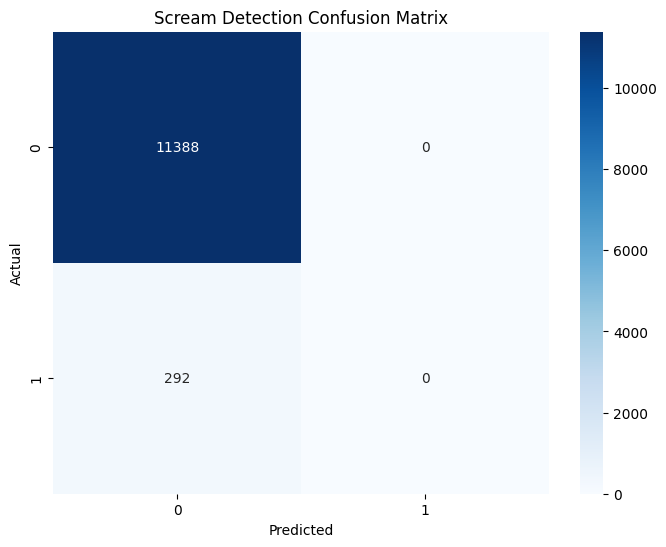

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 테스트 데이터로 예측값 가져오기
print("모델 테스트 중...")
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# 실제 정답값 가져오기 (배치 단위로 묶여 있어 재추출 필요)
y_true = []
for i in range(len(test_generator)):
    _, labels = test_generator[i]
    y_true.extend(labels)
y_true = np.array(y_true[:len(y_pred_classes)]) # 개수 맞추기

# 2. 성능 보고서 출력 (Scream인 1번을 얼마나 맞췄는지가 핵심!)
print("\n--- 상세 성능 보고서 ---")
print(classification_report(y_true, y_pred_classes, target_names=['Notscream', 'Scream']))

# 3. 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Scream Detection Confusion Matrix')
plt.show()

In [26]:
import os

def create_label_map_fixed(feature_path):
    all_files = [f for f in os.listdir(feature_path) if f.endswith('.npy')]
    data_list = []
    labels = []

    for f in all_files:
        full_path = os.path.join(feature_path, f)
        data_list.append(full_path)
        
        # 'scream' 또는 'aug_scream'이 들어간 파일을 모두 1로 지정
        if 'scream' in f.lower():
            labels.append(1)
        else:
            labels.append(0)
                
    return data_list, labels

X_files, y_labels = create_label_map_fixed('preprocessed_features')
print(f"전체 파일: {len(X_files)}, Scream 파일: {sum(y_labels)}")

전체 파일: 58539, Scream 파일: 1461


In [27]:
import numpy as np
import os
from tqdm import tqdm

def final_augment_scream(source_root, save_path, target_count=20000):
    if not os.path.exists(save_path): os.makedirs(save_path)
    
    # 원본 Scream 폴더 (파일명 확인 결과 'Scream' 폴더)
    scream_dir = os.path.join(source_root, 'Scream') 
    scream_files = [f for f in os.listdir(scream_dir) if f.endswith('.wav')]
    
    current_scream_count = 1461 # 현재 확인된 개수
    needed_count = target_count - current_scream_count
    
    print(f"현재 Scream: {current_scream_count}개 -> {target_count}개까지 증강 시작")

    for i in tqdm(range(needed_count), desc="Scream 증강 중"):
        random_file = np.random.choice(scream_files)
        file_path = os.path.join(scream_dir, random_file)
        
        # 멜-스펙트로그램 추출 (기존 정의된 함수 사용)
        feature = preprocess_for_accuracy(file_path)
        
        if feature is not None:
            # 변동성을 주기 위해 노이즈 강도를 랜덤하게 조절
            noise_level = np.random.uniform(0.001, 0.01)
            noise = np.random.normal(0, noise_level, feature.shape)
            aug_feature = feature + noise
            
            # 파일명에 'scream'이 반드시 포함되게 저장 (중요!)
            np.save(os.path.join(save_path, f"final_aug_scream_{i}.npy"), aug_feature)

# 실행
final_augment_scream('raw_data/Processed_Data_Full', 'preprocessed_features')

현재 Scream: 1461개 -> 20000개까지 증강 시작


Scream 증강 중: 100%|██████████| 18539/18539 [03:13<00:00, 95.90it/s] 


In [28]:
# 1. 라벨 맵 재생성
X_files, y_labels = create_label_map_fixed('preprocessed_features')
print(f"최종 데이터 확인 - 전체: {len(X_files)}, Scream: {sum(y_labels)}")

# 2. 데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X_files, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# 3. 데이터 로더 생성
train_generator = DataGenerator(X_train, y_train, batch_size=32)
test_generator = DataGenerator(X_test, y_test, batch_size=32)

# 4. 클래스 가중치 계산 (불균형 해소의 핵심)
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)
weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("적용될 가중치:", weight_dict)

최종 데이터 확인 - 전체: 77078, Scream: 20000
적용될 가중치: {0: np.float64(0.6751988506955394), 1: np.float64(1.92695)}


In [29]:
# 새 모델 생성
model = build_model((128, 157, 1))

# 학습 (class_weight 추가)
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    class_weight=weight_dict
)

model.save('scream_detection_v2.keras')

Epoch 1/10


/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1926/1926 ━━━━━━━━━━━━━━━━━━━━ 65s 33ms/step - accuracy: 0.5643 - loss: 0.8777 - val_accuracy: 0.6815 - val_loss: 0.5156
Epoch 2/10
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.6276 - loss: 0.5077 - val_accuracy: 0.6381 - val_loss: 0.4993
Epoch 3/10
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.6283 - loss: 0.4939 - val_accuracy: 0.6446 - val_loss: 0.4730
Epoch 4/10
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.6293 - loss: 0.4924 - val_accuracy: 0.6248 - val_loss: 0.5266
Epoch 5/10
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.6302 - loss: 0.5029 - val_accuracy: 0.6259 - val_loss: 0.5199
Epoch 6/10
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.6309 - loss: 0.4864 - val_accuracy: 0.6320 - val_loss: 0.5141
Epoch 7/10
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.6301 - loss: 0.4909 - val_accuracy: 0.6268 - val_loss: 0.5217
Epoch 8/10
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 63s 32ms/step - accuracy: 0.6324 - loss: 0.48

481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step

--- [V2 모델] 상세 성능 보고서 ---
              precision    recall  f1-score   support

   Notscream       0.74      0.38      0.50     11399
      Scream       0.26      0.61      0.36      3993

    accuracy                           0.44     15392
   macro avg       0.50      0.49      0.43     15392
weighted avg       0.61      0.44      0.46     15392



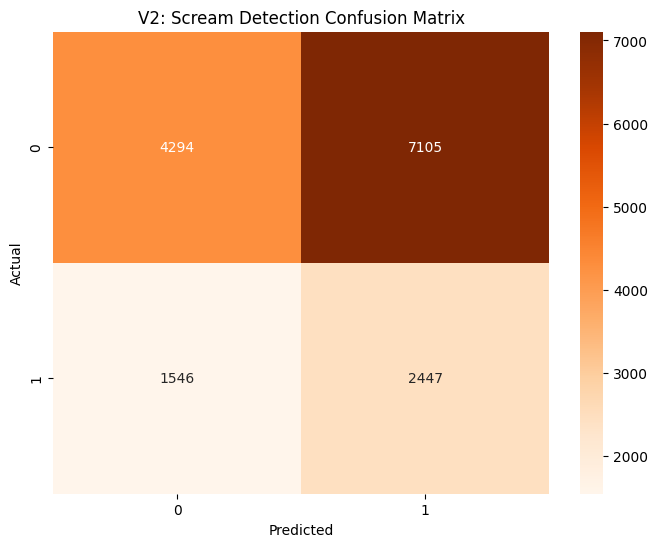

In [30]:
# 이 코드를 다시 실행해서 결과를 확인해 보세요!
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = []
for i in range(len(test_generator)):
    _, labels = test_generator[i]
    y_true.extend(labels)
y_true = np.array(y_true[:len(y_pred_classes)])

print("\n--- [V2 모델] 상세 성능 보고서 ---")
print(classification_report(y_true, y_pred_classes, target_names=['Notscream', 'Scream']))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('V2: Scream Detection Confusion Matrix')
plt.show()

In [31]:
def build_advanced_model(input_shape):
    model = models.Sequential([
        # 첫 번째 블록
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # 두 번째 블록
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # 세 번째 블록 (추가)
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 새 모델 생성
model = build_advanced_model((128, 157, 1))

/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 가중치는 아까 계산한 weight_dict를 그대로 사용합니다.
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20, # 넉넉히 주되 early_stop이 알아서 멈춥니다.
    class_weight=weight_dict,
    callbacks=[early_stop]
)

Epoch 1/20
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 185s 95ms/step - accuracy: 0.6025 - loss: 0.5871 - val_accuracy: 0.6084 - val_loss: 0.5264
Epoch 2/20
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 183s 95ms/step - accuracy: 0.6072 - loss: 0.5070 - val_accuracy: 0.6001 - val_loss: 0.5390
Epoch 3/20
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 186s 96ms/step - accuracy: 0.6109 - loss: 0.5073 - val_accuracy: 0.5661 - val_loss: 0.5871
Epoch 4/20
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 184s 95ms/step - accuracy: 0.6113 - loss: 0.4967 - val_accuracy: 0.6257 - val_loss: 0.5119
Epoch 5/20
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 183s 95ms/step - accuracy: 0.6190 - loss: 0.4903 - val_accuracy: 0.6250 - val_loss: 0.5163
Epoch 6/20
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 183s 95ms/step - accuracy: 0.6170 - loss: 0.4988 - val_accuracy: 0.6068 - val_loss: 0.5431
Epoch 7/20
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 183s 95ms/step - accuracy: 0.6206 - loss: 0.4878 - val_accuracy: 0.6034 - val_loss: 0.5430


481/481 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step

--- [Advanced 모델] 상세 성능 보고서 ---
              precision    recall  f1-score   support

   Notscream       0.73      0.37      0.49     11396
      Scream       0.26      0.62      0.36      3996

    accuracy                           0.43     15392
   macro avg       0.49      0.49      0.43     15392
weighted avg       0.61      0.43      0.46     15392



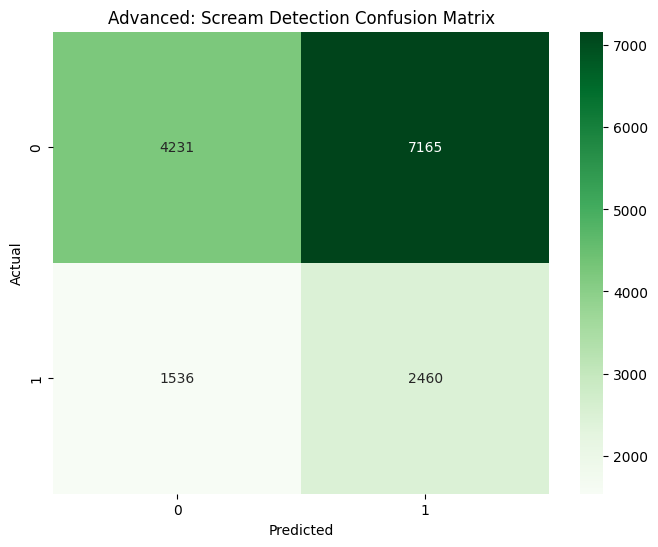

: 

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 테스트 데이터를 통한 예측
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# 실제 정답 추출
y_true = []
for i in range(len(test_generator)):
    _, labels = test_generator[i]
    y_true.extend(labels)
y_true = np.array(y_true[:len(y_pred_classes)])

print("\n--- [Advanced 모델] 상세 성능 보고서 ---")
print(classification_report(y_true, y_pred_classes, target_names=['Notscream', 'Scream']))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Advanced: Scream Detection Confusion Matrix')
plt.show()